In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


2025-11-21 09:06:51.111244: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763716011.368076      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763716011.433896      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-21 09:07:16.677728: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8935 - loss: 0.3560 - val_accuracy: 0.9736 - val_loss: 0.0808
Epoch 2/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9811 - loss: 0.0635 - val_accuracy: 0.9812 - val_loss: 0.0546
Epoch 3/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9883 - loss: 0.0385 - val_accuracy: 0.9802 - val_loss: 0.0628
Epoch 4/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9912 - loss: 0.0266 - val_accuracy: 0.9840 - val_loss: 0.0529
Epoch 5/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9953 - loss: 0.0164 - val_accuracy: 0.9807 - val_loss: 0.0633


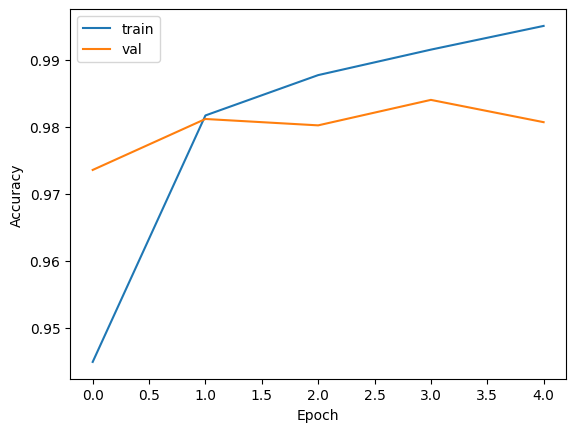

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [2]:
# ===============================
# Step 0: ライブラリの準備
# ===============================
import numpy as np                 # 計算用ライブラリ
import pandas as pd                # データ操作用
import matplotlib.pyplot as plt    # グラフ描画用

from tensorflow.keras.models import Sequential          # モデルを積み重ねるため
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical       # ラベルをone-hot形式に変換

# ===============================
# Step 1: データ読み込み
# ===============================
train = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
test  = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')


X_train = train.iloc[:, 1:].values  # 画像部分（784列）
y_train = train.iloc[:, 0].values   # ラベル（0-9）

# ===============================
# Step 2: 前処理
# ===============================
# 2-1. 0〜255の値を0〜1に正規化（学習が安定する）
X_train = X_train / 255.0

# 2-2. 画像の形にreshape (28,28,1)
X_train = X_train.reshape(-1, 28, 28, 1)

# 2-3. ラベルをone-hotに変換（10クラス分類用）
y_train = to_categorical(y_train, num_classes=10)

# ===============================
# Step 3: モデル作成
# ===============================
# CNNの基本構造
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),  # 画像特徴抽出
    MaxPooling2D((2,2)),                                         # 特徴圧縮
    Flatten(),                                                    # 1次元に変換
    Dense(128, activation='relu'),                                # 全結合層
    Dense(10, activation='softmax')                                # 出力層（10クラス）
])

# ===============================
# Step 4: モデルコンパイル
# ===============================
# 学習方法と評価指標を決める
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ===============================
# Step 5: 学習
# ===============================
history = model.fit(
    X_train,
    y_train,
    epochs=5,                  # データを5回繰り返す
    batch_size=32,             # 32枚ずつ学習
    validation_split=0.1       # 10%を検証用に使う
)

# ===============================
# Step 6: 学習経過をグラフで確認
# ===============================
# 学習中の精度の推移を確認する
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ===============================
# Step 7: 予測（提出用）
# ===============================
X_test = test.values / 255.0                 # 正規化
X_test = X_test.reshape(-1,28,28,1)         # 画像形状に変換
predictions = model.predict(X_test)          # 予測
pred_labels = np.argmax(predictions, axis=1) # 最も確率の高いラベルを取得

submission = pd.DataFrame({
    'ImageId': np.arange(1, len(pred_labels)+1),
    'Label': pred_labels
})

submission.to_csv('submission.csv', index=False)  # 提出ファイル保存
